# Compressed images

## Import

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, data

## Get image

In [164]:
img1 = data.checkerboard()
img2 = color.rgb2gray(data.rocket())
img3 = data.gravel()

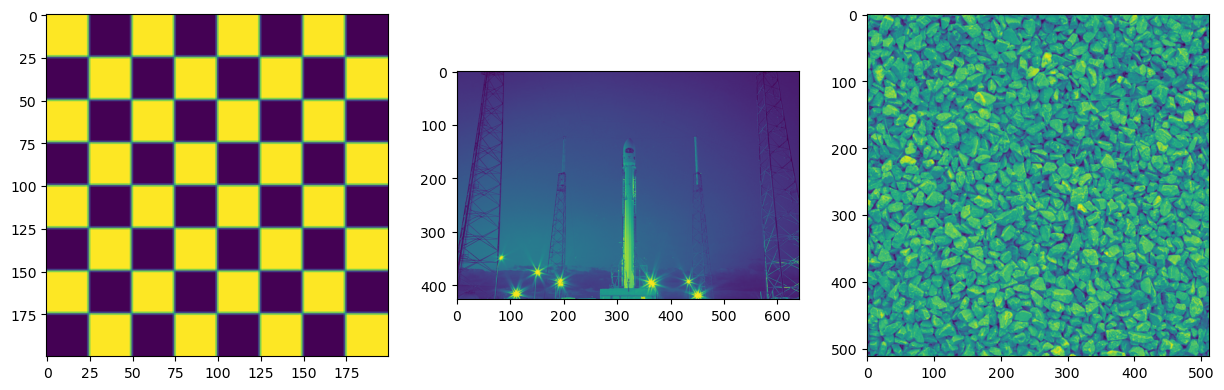

In [165]:
plt.figure(figsize=(15, 6))
for i, img in enumerate([img1, img2, img3]):
    plt.subplot(1, 3, i+1)
    plt.imshow(img)

## Functions

In [ ]:
def compute_svd(img):
    U, S, Vt = np.linalg.svd(img, full_matrices=False)
    return U, S, Vt

def reconstruct(U, S, Vt, k):
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

def plot_spectrum_and_variance(img):
    _, S, _ = compute_svd(img)

    var = S**2
    explained = np.cumsum(var) / np.sum(var)

    fig, ax1 = plt.subplots(figsize=(6, 4))

    color = 'tab:blue'
    # ax1.set_yscale('log')
    ax1.set_xlabel('Index')
    ax1.set_ylabel('Singular value', color=color)
    ax1.plot(S, color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(np.arange(0, len(S), step=50))
    ax1.grid(axis='x')

    ax2 = ax1.twinx()

    color = 'tab:red'
    ax2.set_ylabel('Explained variance ratio', color=color)
    ax2.plot(explained, color=color, linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.grid(axis='y')

    plt.title("Singular Value Spectrum & Explained Variance")
    fig.tight_layout()
    plt.show()

def count_varience(S, k):
    var = S**2
    explained = np.cumsum(var) / np.sum(var)

    return explained[k-1]

def plot_reconstructions(img, ranks, statistic=False):
    U, S, Vt = compute_svd(img)

    plt.figure(figsize=(18, 10))

    for i, k in enumerate(ranks):
        recon = reconstruct(U, S, Vt, k)

        plt.subplot(2, len(ranks)//2, i+1)
        plt.imshow(recon, cmap='gray')
        plt.title(f"k={k}")

        if statistic:
            ev = count_varience(S, k)
            plt.xlabel(f"Explained: {ev:.3f}")

        # plt.axis('off')

    plt.tight_layout()
    plt.show()

## Visualization comressed images

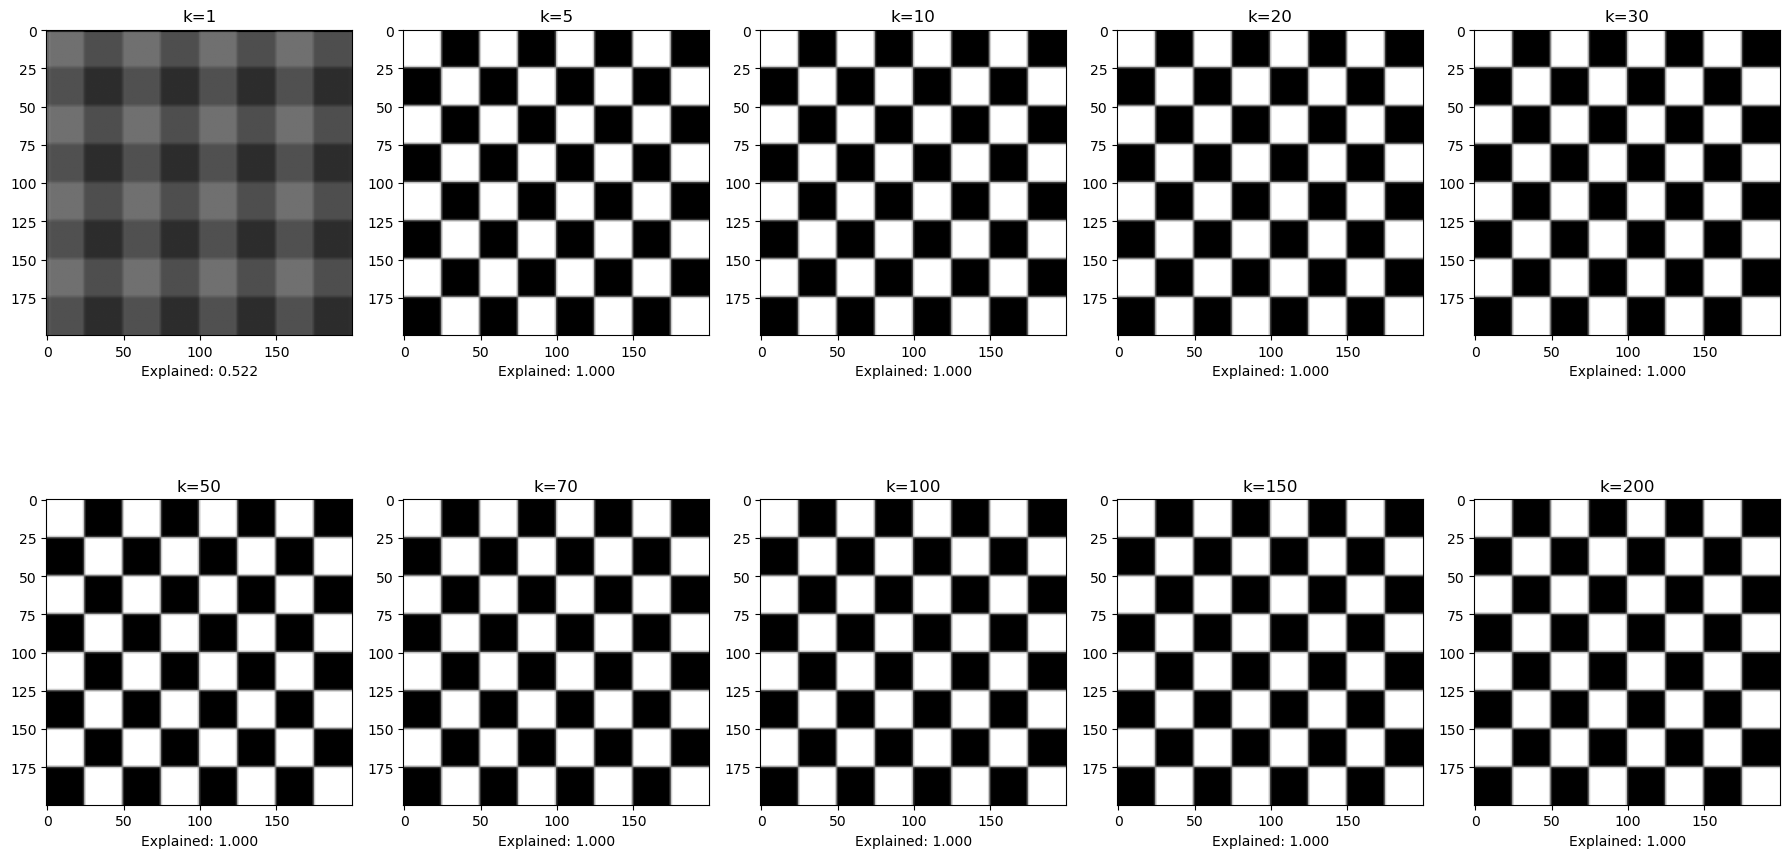

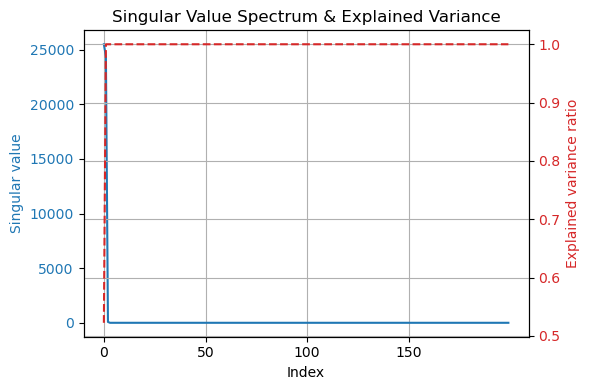

In [168]:
ranks = [1, 5, 10, 20, 30, 50, 70, 100, 150, 200]

plot_reconstructions(img1, ranks, statistic=True)
plot_spectrum_and_variance(img1)

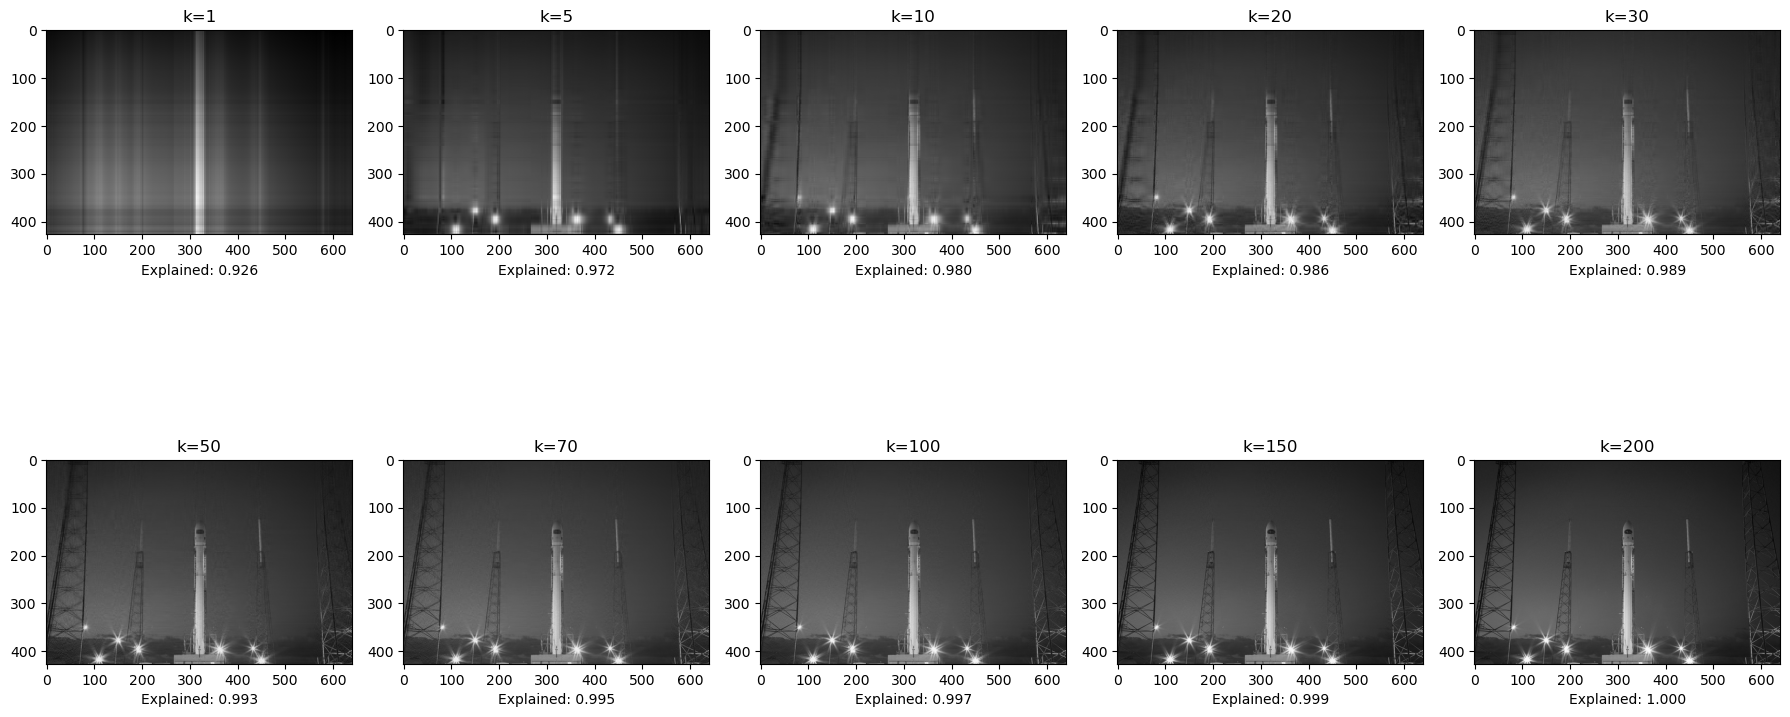

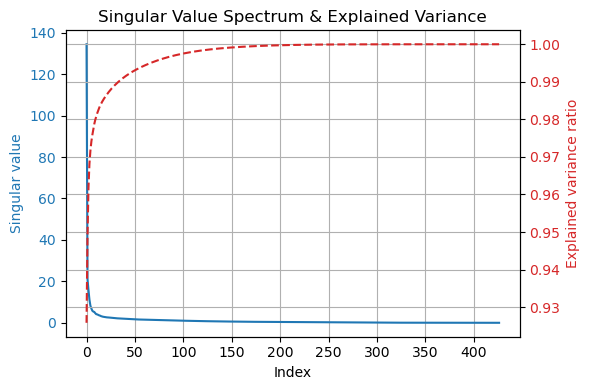

In [169]:
ranks = [1, 5, 10, 20, 30, 50, 70, 100, 150, 200]

plot_reconstructions(img2, ranks, statistic=True)
plot_spectrum_and_variance(img2)

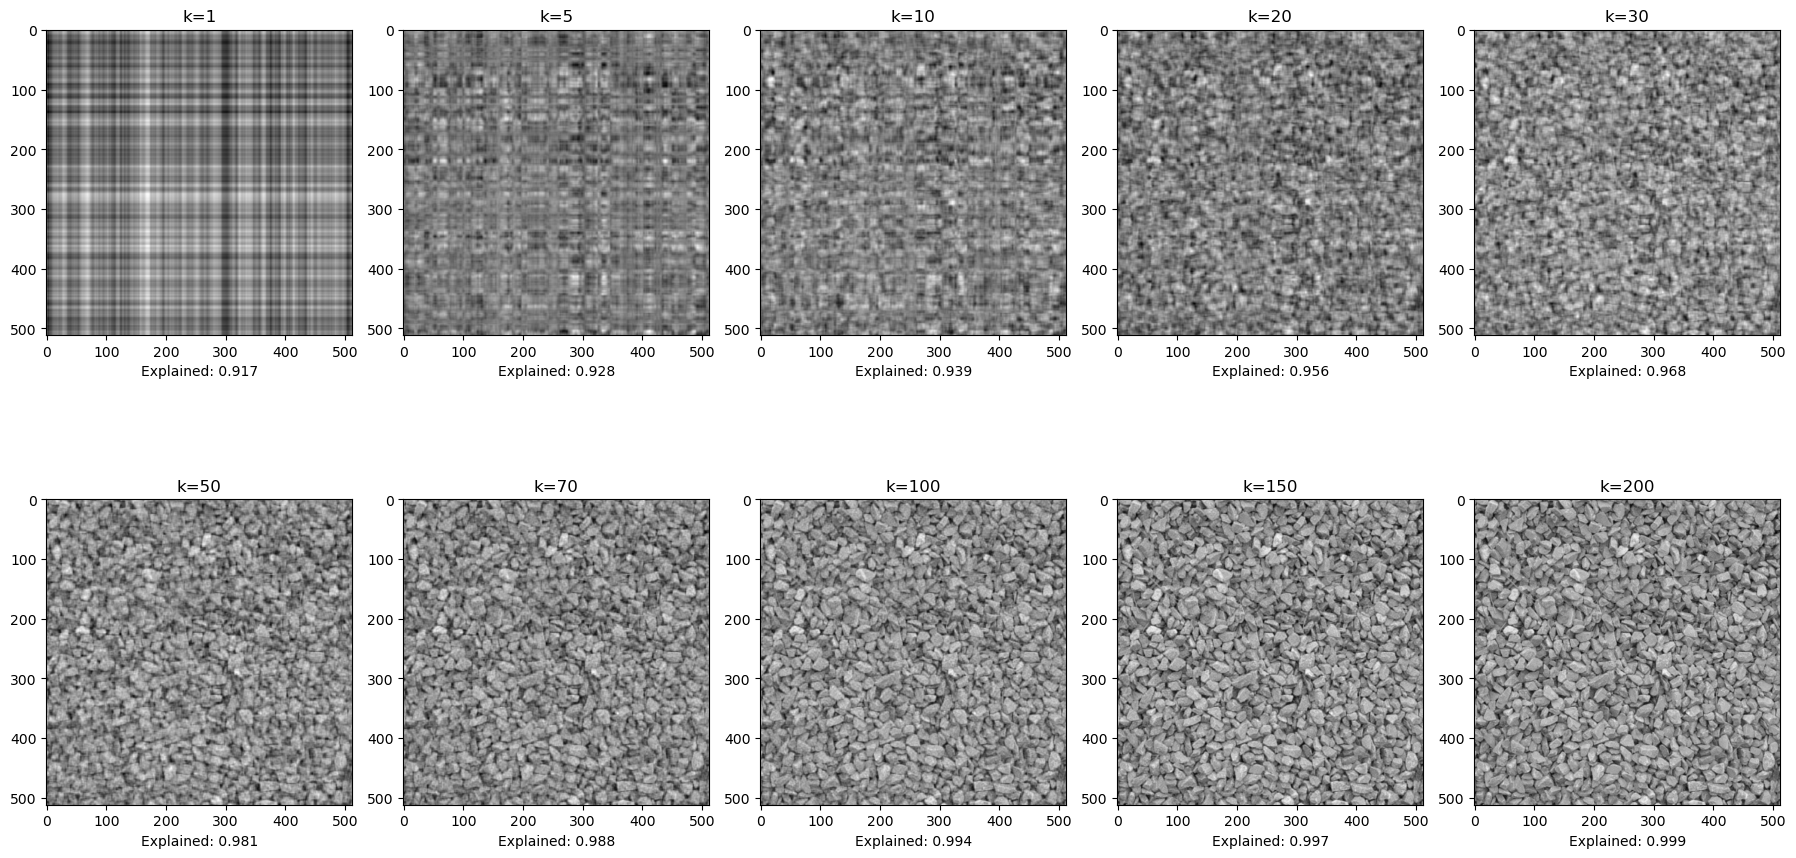

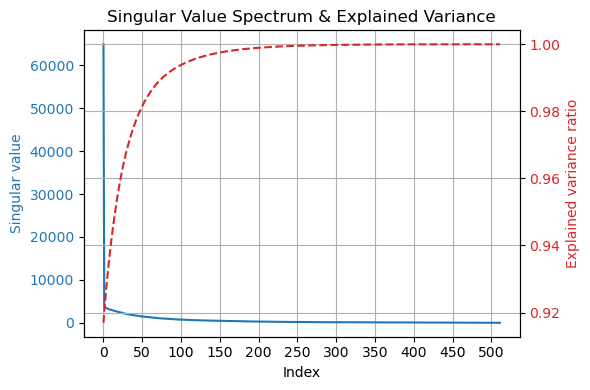

In [170]:
ranks = [1, 5, 10, 20, 30, 50, 70, 100, 150, 200]

plot_reconstructions(img3, ranks, statistic=True)
plot_spectrum_and_variance(img3)

## Conclusion

Спектр сингулярных значений показывает быстрое затухание, что указывает на то, что большая часть важной информации в изображении сосредоточена в первых нескольких компонентах. Скорость затухания зависит от сложности изображения: более простые изображения затухают быстрее, в то время как для более сложных изображений требуется больше компонентов.

Объясненная кривая дисперсии быстро увеличивается и приближается к 1, показывая, что большая часть общей дисперсии определяется небольшим числом сингулярных значений. Это означает, что изображение может быть эффективно аппроксимировано с использованием представления низкого ранга.

На практике для хорошего качества восстановления достаточно примерно 50-100 компонентов, сохраняющих основную структуру изображения, но при этом устраняющих мелкие детали и шум.

В целом, это демонстрирует, что изображения в значительной степени избыточны и могут быть эффективно сжаты с использованием низкоуровневых аппроксимаций на основе SVD.